## Remember what the difference between Python and C/ FORTRAN etc is?

### Python is a versatile language: you can use it to make fast calculations, pretty plots, simple or advanced functions etc and while often you will use it for such things only, you should remember that it also allows you to do object-oriented programming.

### If you want a reminder of all basic things Python you can (re)visit ThinkPython2e (https://greenteapress.com/thinkpython2/thinkpython2.pdf) and our PHZ 3150 material (if applicable). 

### Remember that the basic modules of Python have great online manuals, and all your general questions probably already have an answer on Stackoverflow (https://stackoverflow.com/)

<img src="stackoverflow.png" width=300 height=300 /> (source:redbubble.com)

### --------------------------------------------------------------------------------------------
### The basics
### --------------------------------------------------------------------------------------------

### 1. A brief overview of Python (the behind the scenes stuff)

- basic packages (for us): [numpy](https://numpy.org/), [matplotlib](https://matplotlib.org/), [scipy](https://scipy.org/), [astropy](https://www.astropy.org/) 

- The more you do, the more new stuff you will discover:
    - interested in ML? probably you will work with [Tensorflow](https://www.tensorflow.org/tutorials/quickstart/beginner), [keras](https://keras.io/), [pytorch](https://pytorch.org/), [pandas](https://pandas.pydata.org/), [cuda](https://developer.nvidia.com/cuda-python), etc
    - interested in retrievals? you might want to check out [emcee](https://emcee.readthedocs.io/en/stable/), [ultranest](https://johannesbuchner.github.io/UltraNest/index.html), [pymultinest](https://johannesbuchner.github.io/PyMultiNest/)
        - for specific subtopics there are also more advanced packages. E.g., for exoplanet retrievals: [petitradtrans](https://petitradtrans.readthedocs.io/en/latest/), [formosa](https://formosa.readthedocs.io/en/latest/) etc. 
        


- Dependencies and environments
    - dependencies
        - think of them as 'prereqs' for your package to work
        - for example:
        
        
        <img src="photutilsdepends.png" width=600 height=300 /> (source: https://photutils.readthedocs.io/en/stable/getting_started/install.html)

    - sometimes, you even need to deprecate specific packages(!)
        
    - solution: [environment](https://docs.conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html); super easy to create and work with in python
    
        - in conda you can create an environment with conda create --name <my-env-name>; 
        - you can add more commands that ensure that all dependencies are taken care of
            - e.g., for astropy: conda create --channel conda-forge  --name astropy python
        - you activate your environment with: conda activate myenv
            - everything that happens in myenv stays in myenv!


- modules: files with many functions that do something particular (e.g., the linear algebra part of numpy here https://github.com/numpy/numpy/blob/main/numpy/linalg/_linalg.py )
    - you can also make your own modules
    - when building more advanced code look into classes/methods (object oriented part of python)



## Let's start our Python recap now: 
- how do we start our Python codes?
- what are the most important modules you might use?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#let's also do some os calls too:
import os
import time

In [ ]:
#import pandas as pd

In [ ]:
os.listdir()


In [ ]:
os.mkdir( 'testme' )
os.listdir( )

In [ ]:
os.rmdir( 'testme')
os.listdir( )

## 1. Arrays  & Data

### Make numpy array x1 that starts at 1 and ends (including) at 441 with a step of 22 (aka, its first elements are 1, 23, 45 etc...)

In [3]:
import numpy as np
x1=np.arange(1,442,22)

### Make numpy array y1 that is equal to the x1 to the power of 2 plus x1 ( $y1 = x1^2 + x1$ )

In [4]:
y1 = x1**2 + x1

### Now plot y1 as a function of x1. Make first a simple, fast plot. Then make a publication ready plot.

In [6]:
import matplotlib.pyplot as plt

#let's first turn interactive mode on for the .py file:
plt.ion()
# fast plot:


(array([-100.,    0.,  100.,  200.,  300.,  400.,  500.]),
 [Text(-100.0, 0, '−100'),
  Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500')])

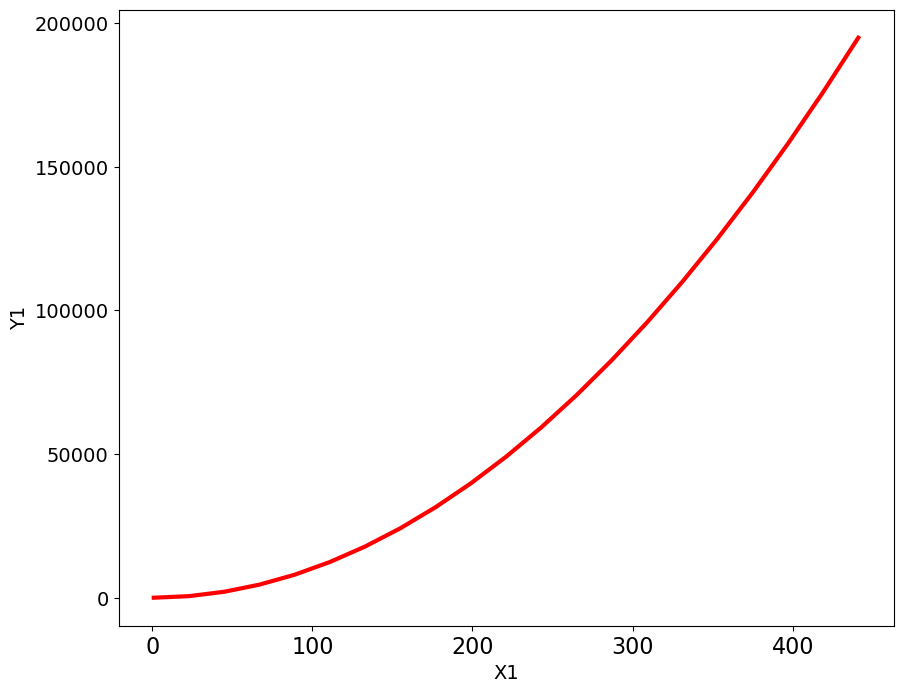

In [7]:
# now let's make it publication ready: 
plt.figure( figsize = (10, 8) )
plt.plot( x1, y1, color = 'red' , linewidth = 3 )
plt.xlabel( 'X1', fontsize = 14 )
plt.ylabel( 'Y1', fontsize = 14 )
#let's also make the y-labels printing every second label:
plt.yticks( np.arange( 0, 200001, 50000), fontsize = 14)
#and increase the x lavels to a size of 16:
plt.xticks( fontsize = 16 )

### when it comes to plotting there are a few libraries out there that can make your plotting more fun like [xkcd_colors](https://xkcd.com/color/rgb/) and other packages that are used for more standardized plotting for different fields likes, e.g., [seaborn](https://seaborn.pydata.org/)

### Reading in data 

- avoid the open() 
    - f = open( filename, 'r' ) 
    - or with open(filename, 'r') as f:    
    - why?
    
- numpy --> great! you can assign directly columns to variables

- if data are good (no gaps)
    - use np.loadtxt() or np.genfromtxt()
        - you can skip lines, even when not marked as headers, with skiprows = ...
        - you can define the delimeter used in data
        - loadtxt() needs all data to be numeric(!)
        - genfromtxt() more flexible; can handle columns being characters

- if data have issues
    - genfromtxt can be used for some cases, but best:
    - pandas



### Let's read data from file *read_data_example.dat* into a numpy array file_data

In [8]:
file_data = np.loadtxt('read_data_example.dat')

In [9]:
#or:
file_data_2 = np.genfromtxt('read_data_example.dat')

In [10]:
#what does your data look like? what is its shape?
np.shape(file_data)

(104, 5)

### assign the first column to array wav, and the 2nd to 5th columns to arrays model_N with N =1 to 4

In [11]:
wav, model_1, model_2, model_3, model_4 = file_data.T

### plot all four models as function of wav in the same plot. Use distinct colors and linestyles for each model and add a legend to show which model is which. Add a labels to indicate that the X axis is the wavelength in microns and the Y axis is models.

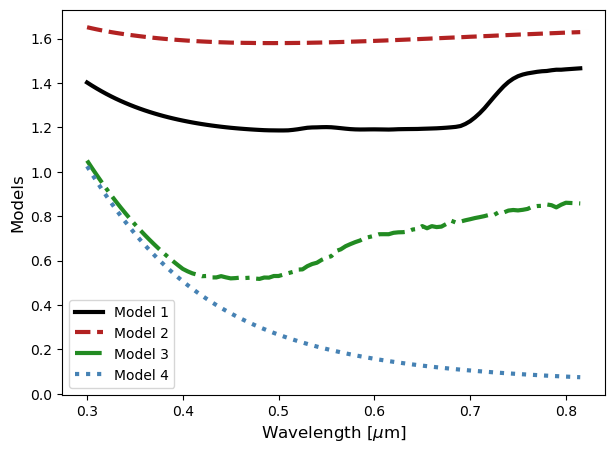

In [13]:
plt.figure( figsize = (7, 5) )

plt.plot( wav, model_1, color = 'black', linewidth = 3 , label = 'Model 1' )
plt.plot( wav, model_2, color = 'firebrick', linewidth = 3, linestyle = '--' , label = 'Model 2')
plt.plot( wav, model_3, color = 'forestgreen', linewidth = 3, linestyle = '-.' , label = 'Model 3')
plt.plot( wav, model_4, color = 'steelblue', linewidth = 3, linestyle = ':' , label = 'Model 4')

plt.xlabel( r'Wavelength [$\mu$m]', fontsize = 12 )
plt.ylabel( 'Models', fontsize = 12 )
plt.legend( fontsize = 10 )



### Great! So we just use numpy all the time and everything is cool?! 
### Not really. Let's get a bigger, awkward dataset. Open omega_cen.csv and browse through it. What is its issue?



In [14]:
#this will crash, empty columns:
omegacen_np = np.loadtxt('omega_cen.csv', skiprows = 1)

ValueError: could not convert string '201.80208247,-47.75028882,' to float64 at row 0, column 1.

In [15]:
#this will not crash initially (it can read text), but then it will. Why?
omegacen_np = np.genfromtxt('omega_cen.csv')

ValueError: Some errors were detected !
    Line #2 (got 10 columns instead of 1)
    Line #3 (got 10 columns instead of 1)
    Line #4 (got 10 columns instead of 1)
    Line #5 (got 10 columns instead of 1)
    Line #6 (got 10 columns instead of 1)
    Line #7 (got 10 columns instead of 1)
    Line #8 (got 10 columns instead of 1)
    Line #9 (got 10 columns instead of 1)
    Line #10 (got 10 columns instead of 1)
    Line #11 (got 10 columns instead of 1)
    Line #12 (got 10 columns instead of 1)
    Line #13 (got 10 columns instead of 1)
    Line #14 (got 10 columns instead of 1)
    Line #15 (got 10 columns instead of 1)
    Line #16 (got 10 columns instead of 1)
    Line #17 (got 10 columns instead of 1)
    Line #18 (got 10 columns instead of 1)
    Line #19 (got 10 columns instead of 1)
    Line #20 (got 10 columns instead of 1)
    Line #21 (got 10 columns instead of 1)
    Line #22 (got 10 columns instead of 1)
    Line #23 (got 10 columns instead of 1)
    Line #24 (got 10 c

In [1]:
import pandas as pd
#in come pandas!
omegacen_pd = pd.read_csv('omega_cen.csv')

In [17]:
#let's look at our data 
omegacen_pd.describe

<bound method NDFrame.describe of           RAJ2000   _DEJ2000 n_Seq     Seq   RAJ2000.1    DEJ2000   pmRA  \
0      201.802082 -47.750289             1  201.802078 -47.750278  -3.25   
1      201.763720 -47.750274             2  201.763730 -47.750272   7.26   
2      201.799369 -47.750249             3  201.799369 -47.750242  -0.41   
3      201.641881 -47.750164             4  201.641896 -47.750155  11.20   
4      201.611637 -47.750130             5  201.611638 -47.750119   0.43   
...           ...        ...   ...     ...         ...        ...    ...   
99994  201.759061 -47.552519        104026  201.759061 -47.552518   0.01   
99995  201.758385 -47.552506        104027  201.758385 -47.552503   0.21   
99996  201.751088 -47.552485        104028  201.751094 -47.552481   4.12   
99997  201.750175 -47.552463        104029  201.750174 -47.552465  -0.55   
99998  201.745469 -47.552487        104030  201.745469 -47.552488  -0.10   

        pmDE    Umag  e_Umag    Bmag  e_Bmag    Vmag 

In [18]:
#let's get the B and V magnitudes (and errors) data and fix any errors that might be in the table:
B     = omegacen_pd['Bmag'].apply(pd.to_numeric, errors='coerce')
B_err = omegacen_pd['e_Bmag'].apply(pd.to_numeric, errors='coerce')
V     = omegacen_pd['Vmag'].apply(pd.to_numeric, errors='coerce')
V_err = omegacen_pd['e_Vmag'].apply(pd.to_numeric, errors='coerce')

In [5]:
B     = np.array(omegacen_pd['Bmag'].apply(pd.to_numeric, errors='coerce'))
print ('minmax', np.min(B), np.max(B))

minmax nan nan


In [6]:
print ('minmax', np.nanmin(B), np.nanmax(B))
# nan=non real number

minmax 10.874 25.236


In [8]:
# Color magnitude diagram 
# %matplotlib notebook allows you to interact
plt.errorbar( B-V, V, yerr = V_err, xerr = np.sqrt( B_err**2 - V_err**2 ) , linestyle = '')
dm = plt.ylim( 26, 10 )

NameError: name 'plt' is not defined

In [20]:
print( B/V )

0        1.034926
1        1.030673
2        1.035810
3        1.034384
4        1.030844
           ...   
99994    1.035130
99995    1.036398
99996    1.039851
99997    1.035801
99998    1.044196
Length: 99999, dtype: float64


### pandas work like numpy, but a bit more memory-heavy; great though once you start entering the BIG data realm

### Let's practice some array slicing and masking
- print wav from element 5 to (and including) element 10
- print wav from element 5 to element 53 with a step of 4
- print the values of model_2 only for wavelengths between 0.4 and 0.5 microns
- print the values of model_1 only for those wavelengths for which model_3 is larger than 0.7 

In [21]:
print(wav[5:11]) 


[0.325 0.33  0.335 0.34  0.345 0.35 ]


In [22]:
print(wav[5:54:4])

[0.325 0.345 0.365 0.385 0.405 0.425 0.445 0.465 0.485 0.505 0.525 0.545
 0.565]


In [24]:
print(model_2[np.where(np.logical_and (wav>=0.4, wav<=0.5))])

[1.59207 1.59053 1.58933 1.58796 1.58677 1.58572 1.58476 1.58374 1.58304
 1.58233 1.58156 1.58119 1.58077 1.58035 1.58024 1.57981 1.57953 1.57949
 1.57943 1.57937 1.57957]


In [25]:
# or with numpy:
print(model_1[np.where(model_3>0.7)] )

[1.40193 1.38818 1.37513 1.36268 1.35088 1.33969 1.32909 1.31911 1.30968
 1.30071 1.29224 1.28426 1.27673 1.1904  1.19071 1.19083 1.19059 1.19031
 1.18996 1.19058 1.1915  1.19187 1.19218 1.1924  1.19262 1.19343 1.19408
 1.19479 1.19554 1.19677 1.19821 1.2     1.20204 1.20593 1.21507 1.22758
 1.24421 1.26367 1.28598 1.31147 1.33696 1.36138 1.38456 1.40395 1.419
 1.43029 1.43783 1.44295 1.44647 1.45007 1.45256 1.45381 1.45708 1.4595
 1.45947 1.46126 1.46276 1.46428 1.46579]


In [26]:
print(model_3 > 0.7 )

[ True  True  True  True  True  True  True  True  True  True  True  True
  True False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]


In [27]:
#what do your masks do on their own?
print(np.where(model_3>0.7) )

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
        71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
        84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,
        97,  98,  99, 100, 101, 102, 103]),)


In [ ]:
# or with numpy:
print(  )

### What is the minimum value of model_3, the mean value of model_4 and the maximum of model_2? Write informative sentences that let the user of your code know.

In [29]:
print('The min of model_3 is:' , model_3.min())
print('The mean of model_4 is:', np.mean(model_4))
print('The max of model_2 is:' , np.max(model_2) )

The min of model_3 is: 0.517187
The mean of model_4 is: 0.30150964999999996
The max of model_2 is: 1.6509


### Read the 2D data from file *2Ddata_example.dat* in an appropriately named array. Can you name it 2Ddata? Why/Why not?

In [35]:

# = np.genfromtxt( '2Ddata_example.dat' )

twoDdata = np.genfromtxt('2Ddata_example.dat')

### Print the data from column 11 to 29 and lines 6 to 12

In [36]:
print(twoDdata[6:13, 11:30])

[[0. 0. 0. 0. 0. 5. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 3. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0. 3. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0. 3. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 3. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 4. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### Plot the 2D dataset. How can you do it? 

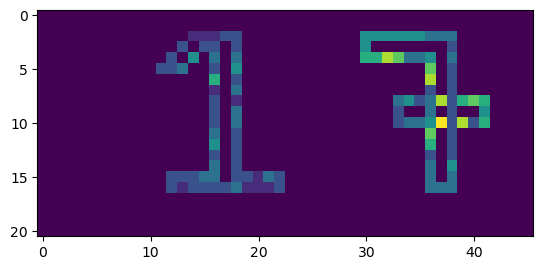

In [37]:
# try plt.imshow:
plt.imshow(twoDdata)

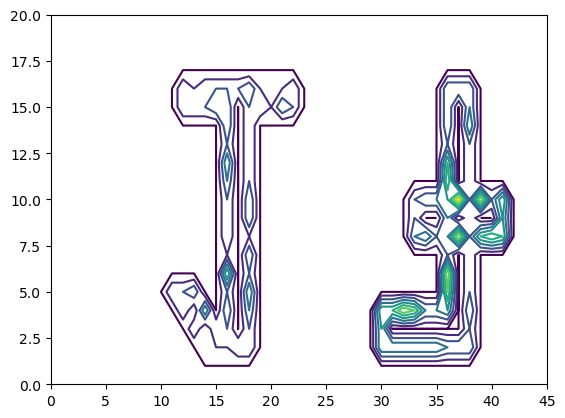

In [38]:
#try contour and contourf plot:
plt.contour(twoDdata)

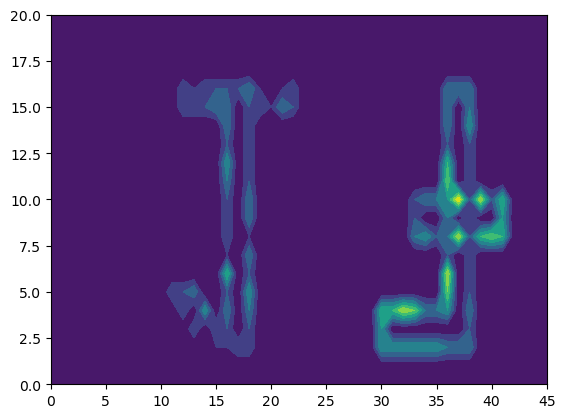

In [39]:
plt.contourf( twoDdata )

In [ ]:
# do you see why the last 2 flip the image? 
# y-axis goes from 0 to 20 for the 20 lines of data....element 0 is on the top of your data, but bottom of your 
# y-axis plot and is thus flipped...
# how do we fix it ?

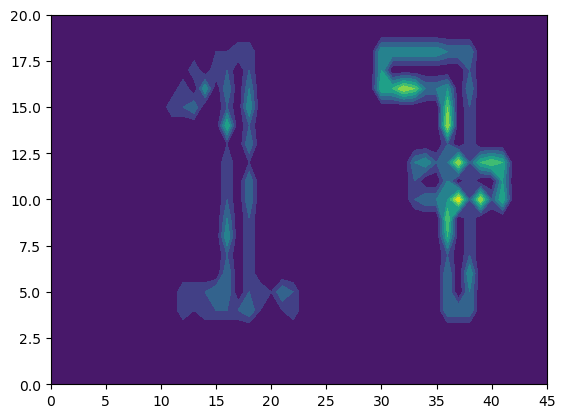

In [41]:
# flipped on 0 axis
dm = plt.contourf( np.flip( twoDdata, 0) )

In [42]:
#or
#plt.contourf( two_dim_data )
#dm = plt.gca().invert_yaxis()

## 2. Strings, lists, tuples, dictionaries and math in Python

In [43]:
string_one = 'hello '
string_two = 'world'

In [44]:
print( string_one + string_two )


hello world


In [45]:
print( string_one * 2 )

hello hello 


### do you remember why the + and * can work as they do here?


### In contrast, this is normal math:

In [46]:
x = 5 
y = 8

z1 = x + y 
z2 = x - y
z3 = x * 3
z4 = x ** 2
z5 = np.sqrt( y )


In [47]:
print( z1, z2, z3, z4, z5 )

13 -3 15 25 2.8284271247461903


In [48]:
#how does the / operator work?

print( y / x )

1.6


#### Note that this is something you should keep in mind, because in some languages 5 and 8 would be treated as integers, and the / would do an integer division like:


In [49]:
print( y // x )

1


### You should always make sure to test that your code does what you intend it to. Always remember the golden rule of coding!

In [50]:
w_in1 = input( 'Give me the numerator ' )
w_in2 = input( 'Give me the denominator ')

Give me the numerator  4
Give me the denominator  36


In [ ]:
#why would this crash?
#print('The result of your division is: ', w_in1/ w_in2 )

In [51]:
#the fix:
print('The result of your division is: ', float(w_in1)/ float(w_in2) )

The result of your division is:  0.1111111111111111


### We recorded the distances a car travels over time and decided to put them in two lists. Make a list *distances* that contains numbers: 0.1 , 0.5, 0.9, 1.4 and a list *times* that contains numbers 0.1, 0.2,  0.3, 0.4. Make a list *speeds* with the speed of the car at each timestamp

In [10]:
distances = np.array ([ 0.1, 0.5, 0.9, 1.4 ])
times     = np.array ([ 0.1, 0.2, 0.3, 0.4 ])

In [11]:
# can we do speeds = distances/times? why/ why not?
speeds = distances / times
speeds

array([1. , 2.5, 3. , 3.5])

In [12]:
#how do we do it then?
d= 0.5 * distances
d

array([0.05, 0.25, 0.45, 0.7 ])

### Do the same thing with tuples now:

In [15]:
distances_t = ( 0.1, 0.5, 0.9, 1.4 )
times_t     = ( 0.1, 0.2, 0.3, 0.4 )

In [16]:
# would speeds_t = distances_t/times_t work?

In [17]:
# how can we make it work? 

#what is the vital difference tuples have in comparison to lists or arrays?
# Can't reassign values in tuples

In [18]:
# How to add elements to tuples: redefining variable
speeds_t = ()
# id to variables you name
print( id( speeds_t) )
for i in range( len( times )):
    speeds_t = speeds_t + ( distances_t[ i ] / times_t[ i ], )
    
#print( speeds_t )
print( id( speeds_t) )

4341580216
4815231936


In [19]:
#vs:
speeds = []
print( id( speeds) )
for i in range( len( times )):
   speeds.append( distances[ i ] / times[ i ] )
print( speeds )
print( id( speeds) )

4772865664
[np.float64(1.0), np.float64(2.5), np.float64(3.0), np.float64(3.4999999999999996)]
4772865664


In [ ]:
# another example to remember the differences between them:

num_1 = np.array( [ 5, 3, 2 ] )
lis_1 = [ 5, 3, 2 ]
tup_1 = ( 5, 3, 2 )


In [ ]:
#oops! we made an error, all 5s should have been -5! Change them and print again num_1, lis_1 and tup_1

In [ ]:
num_1[ 0 ] = -5
print( num_1 )

In [ ]:
lis_1[ 0 ] = -5 
print( lis_1 )

In [ ]:
#tup_1[ 0 ] = -5 

In [ ]:
tup_1 = (-5,) + tup_1[ 1: ]
print( tup_1 )

### And then, there are also dictionaries:

In [ ]:
dict_1 = { 'Jane': 5, 'Joe': 8, 'Mary': 10 }
print( dict_1[ 'Jane'] )

In [20]:
omega_frame = pd.DataFrame(data={
    'Bmags': B,
    'V': V
})
omega_frame.to_csv('omega_values.csv')

NameError: name 'V' is not defined

## Lists etc have their purpose, but are not handy for working with numbers and big datasets so, generally, we don't use them in astronomy

### Overall, when coding things
    - if possible to use power of numpy do so!
        - avoiding for loops saves time 

In [21]:
%%time
N = 1000000
x = range(N)
y = range(N)
z = []

for i in range(len(x)):
    z.append(x[i] * y[i])

CPU times: user 107 ms, sys: 5.31 ms, total: 112 ms
Wall time: 112 ms


In [ ]:
#vs


In [22]:
%%time
x = np.arange(N)
y = np.arange(N)
z = x * y 

CPU times: user 12.7 ms, sys: 6.64 ms, total: 19.3 ms
Wall time: 20 ms


### ------------------------------------------------------------------------
###  Functions
### ------------------------------------------------------------------------

### Often you find yourself needing to use a specific code again and again. You have 2 options:
   - rewrite the code/ copy-paste it in your code again and again and again and.........
   - make a function: small code snippet that you can import in your code and use it 
        - important thing to consider: where is your function?
            - generally, you want it in the same dir (e.g., the ast4762c/)
            - you might consider making a globally accesible dir, but only need it if func needs to be accessible from many different projects
    

In [ ]:
def FtoC(F):
    """Converts the temperature from F to C. 
    Input: temperature in F
    Output: temperature in C 
    
    Function uses the equation: C = (F - 32) * 5/9 to 
    calculate the temperature in C, when a temperature in F is provided.
    
    
    Examples: 
    >> print( FtoC(100) ) should return 37.78
    >> print( FtoC(40) ) should return 4.44
    >> print( FtoC(0) ) should return -17.78
    >> print( FtoC(-40) ) should return -40
    
    Written: 08/01/2025 TK
    Updates: 
     - added more examples 08/18/2025  TK
    
    """
    
    C = (F - 32.) * 5./9.
    
    return C

In [ ]:
print( FtoC(100) )
print( FtoC(40) )
print( FtoC(0) )
print( FtoC(-40) )


### - why is a good docstring important?/


In [ ]:
#import function 

from undocumented_function import rando_func

#I just remember it makes a sin func plot and has 2 inputs. One for amplitude and 
# one for periods; do not remember much more though. Let's see what happens when I plot
# A = 2. B = 0.3 or A = 0.3 and B = 2.

In [ ]:
A, B = 2.0, 0.3

plt.plot( rando_func( A,B) )

A, B = 0.3, 2.0
dm = plt.plot( rando_func( A,B) )


### this example is a bit easy to visualize what is what, and you can easily read the func too; but imagine having a proper function with hundreds of lines 

In [ ]:
help(np.linspace)

## You may chose to get pyds9 installed:
- Start by getting SAOImage DS9 from here: https://sites.google.com/cfa.harvard.edu/saoimageds9/download 
- On your terminal type: pip install pyds9 This should get the job done 
    - if you have a Mac you might need to install XQuartz first. To do that, type in your terminal : brew install --cask xquartz. If there are hiccups with the installation, ask us for help!
## But you really don't have to!

In [ ]:
#import pyds9

In [ ]:
x = np.ones((200, 500)) # make an array (details later)
x[100,:] = np.arange(500) # with a stripe down the middle
print( x ) # print x to see - stripe??
# display as an image


In [ ]:
fig,ax = plt.subplots( figsize = (8,5) )
pos = ax.imshow(x, cmap='Greys', interpolation='none')

# add the colorbar using the figure's method,
# telling which mappable we're talking about and
# which axes object it should be near
fig.colorbar(pos, ax=ax)


In [ ]:
#ds9 = pyds9.DS9() # connect to DS9; start if needed



In [ ]:
#ds9.set_np2arr(x) # send array x to ds9 for viewing
# Now see stripe, get values, etc.


### ---------------------------------------------

### Good coding style

### coding in good style is critically important to successful science!
- Often, we don't know the right answer - why we're scientists
- How to know if code is producing right answer if we don't know the answer?

- Good style makes code easier to verify
    - Spend much less time debugging good code
    - Make far fewer mistakes to begin with
    - DO NOT write sloppy and "clean it up later"! You will write more bugs.
    - Write slowly and well the first time
    - Spend the time debugging early on; saves more time later (remember golden rule!)
    

- See our homework_format_rules.pdf and our class this week where we will talk about this in detail!


### Programming done in text.
- Text is communication; follow the 3 rules of communication:
    - Know your subject
    - Know your audience (viewer, listener, etc.)
    - Know exactly what you want your audience to know about your subject

- How do these apply to code?
    - Knowing subject can be hard! (algorithms and data can be complex)
    - Recipients: computer, you (sooner & later), colleagues, students (examples)

    - Write enough and good comments on your code!

    - Check input values - right type, right range
    - Use consistent internal units, document, convert inputs immediately
    - Write functions? Write good docstrings!!!

    - Use horizontal and vertical spaces for clarity and ease of verification
    - Avoid hard-coding values except 0 and 1! Put at top in variables if necessary, or pass into functions. (There are limits to this.)
    - Query data for items like image sizes that vary from one analysis to another, or pass them if necessary
    - Document any modifications of code input (ok for arrays, otherwise avoid)

In [ ]:
x = (4 * 2) + 20 -  \
